In [131]:

print(lgb.__version__)

4.6.0


In [132]:
# read main drl input csv
drl_data = pd.read_csv(
    "../data/data_2019-01-01_2024-12-31_hourly.csv",
    parse_dates=["time"],
    index_col="time",
)
drl_data.index = pd.to_datetime(drl_data.index, utc=True)
drl_data.drop(columns=["id_full_qh"], inplace=True)

In [133]:
# read rolling intrissnc profit data
ri_profit1 = pd.read_csv("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv")
ri_profit2 = pd.read_csv("../output/single_market/rolling_intrinsic/ri_basic/qh/2023/bs15cr1rto0.86mc365mt10/profit.csv")

ri_profit = pd.concat([ri_profit1, ri_profit2], ignore_index=True)
ri_profit = ri_profit.set_index("day")

idx = ri_profit.index.astype(str).str.slice(0, 19)
idx = pd.to_datetime(idx)
idx = idx.tz_localize("UTC")
ri_profit.index = idx
ri_profit.index.name = "date"
ri_profit = ri_profit.drop(columns=["cycles"])
ri_profit = ri_profit.rename(columns={"profit": "ri_profit"})
ri_profit.describe()

,ri_profit
count,1826.000000
mean,179.591671
std,156.884145
min,17.538780
25%,74.912292
50%,129.876447
75%,233.856328
max,2377.600615


In [134]:
# day ahead milp profit based on exaa price forecast
da_milp_profit_exaa = pd.read_csv("../output/myopic_multi_market/day_ahead_milp/da_milp_results_exaa.csv")
da_milp_profit_exaa["time"] = pd.to_datetime(da_milp_profit_exaa["time"], utc=True)
da_milp_profit_exaa = da_milp_profit_exaa.set_index("time")
da_milp_profit_exaa = da_milp_profit_exaa.resample("D").sum()
da_milp_profit_exaa["da_profit_exaa"] = da_milp_profit_exaa["discharge_revenues"] + da_milp_profit_exaa["charge_costs"]
da_milp_profit_exaa = da_milp_profit_exaa[["da_profit_exaa"]]
da_milp_profit_exaa.describe()

,da_profit_exaa
count,2192.000000
mean,66.173015
std,72.389930
min,-458.095834
25%,19.410546
50%,41.871897
75%,95.516168
max,798.356543


In [135]:
# # day ahead milp profit based on epex prices (perfect forecast)
da_milp_profit_epex = pd.read_csv("../output/myopic_multi_market/day_ahead_milp/da_milp_results_epex.csv")
da_milp_profit_epex["time"] = pd.to_datetime(da_milp_profit_epex["time"], utc=True)
da_milp_profit_epex = da_milp_profit_epex.set_index("time")
da_milp_profit_epex = da_milp_profit_epex.resample("D").sum()
da_milp_profit_epex["da_profit_epex"] = da_milp_profit_epex["discharge_revenues"] + da_milp_profit_epex["charge_costs"]
da_milp_profit_epex = da_milp_profit_epex[["da_profit_epex"]]
da_milp_profit_epex.describe()

,da_profit_epex
count,2192.000000
mean,71.420266
std,75.658919
min,-176.526132
25%,21.619986
50%,47.313139
75%,103.902538
max,752.511870


In [136]:
profit_data = pd.concat([ri_profit, da_milp_profit_exaa, da_milp_profit_epex], axis=1)
profit_data["da_idc_profit_diff"] = profit_data["da_profit_epex"] - profit_data["ri_profit"]
profit_data = profit_data.loc["2019-01-01":"2023-12-31"]
profit_data.describe()

,ri_profit,da_profit_exaa,da_profit_epex,da_idc_profit_diff
count,1826.000000,1826.000000,1826.000000,1826.000000
mean,179.591671,61.109065,66.708093,-112.883578
std,156.884145,70.633017,74.919473,110.789202
min,17.538780,-458.095834,-176.526132,-2225.924762
25%,74.912292,17.957985,19.437774,-143.085730
50%,129.876447,36.107373,41.834264,-81.857635
75%,233.856328,85.018755,91.727302,-49.529689
max,2377.600615,798.356543,635.517841,120.146749


<Axes: >

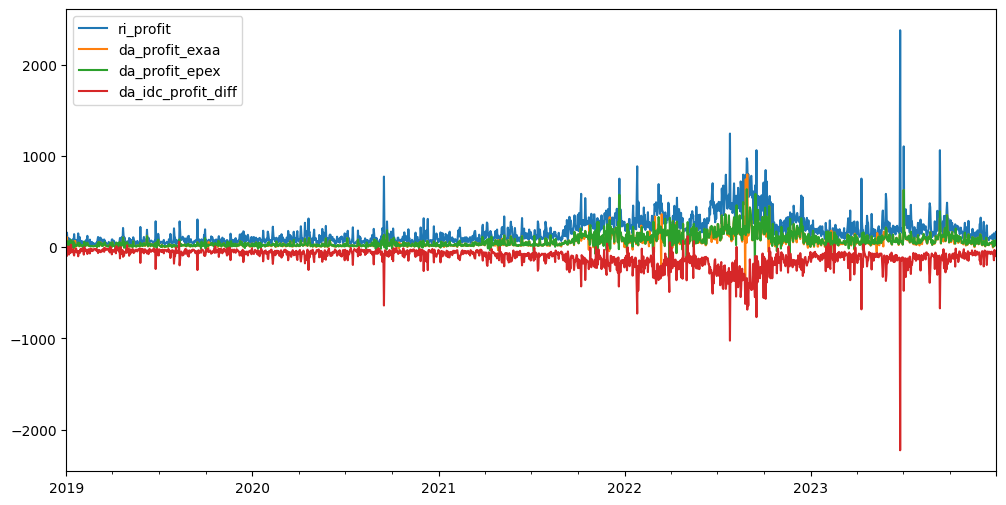

In [137]:
profit_data.plot(figsize=(12, 6))

In [138]:
profit_data.loc["2022-11-01":"2022-12-31"].describe()

,ri_profit,da_profit_exaa,da_profit_epex,da_idc_profit_diff
count,61.000000,61.000000,61.000000,61.000000
mean,273.952679,109.474748,122.794263,-151.158416
std,94.286233,62.070902,78.814783,61.411290
min,56.662397,-6.779662,-81.047112,-315.514891
25%,203.977726,64.221533,70.130769,-182.867939
50%,283.480949,105.994871,116.555798,-147.082586
75%,323.249503,152.583590,171.228308,-111.019690
max,566.068367,248.468276,318.029688,7.980099


### Add features

In [139]:
drl_data.rename(columns={"epex_spot_60min_de_lu_eur_per_mwh": "epex_price",
                         "exaa_15min_de_lu_eur_per_mwh": "exaa_price",
                         "load_forecast_d_minus_1_1000_total_de_lu_mw": "load_forecast",
                         "pv_forecast_d_minus_1_1000_de_lu_mw": "pv_forecast",
                         "wind_offshore_forecast_d_minus_1_1000_de_lu_mw": "wind_offshore_forecast",
                        "wind_onshore_forecast_d_minus_1_1000_de_lu_mw": "wind_onshore_forecast",
                         }, inplace=True)
drl_data

,epex_price,load_forecast,pv_forecast,wind_offshore_forecast,wind_onshore_forecast,id_full_h,exaa_price
time,,,,,,,
2018-12-31 23:00:00+00:00,28.32,43647.5450,0.0,5068.9000,18879.7900,30.006208,20.00
2019-01-01 00:00:00+00:00,10.07,41692.5650,0.0,5042.4425,20626.5625,7.277301,13.54
2019-01-01 01:00:00+00:00,-4.08,40587.2325,0.0,5028.4175,22355.6850,7.113798,5.59
2019-01-01 02:00:00+00:00,-9.91,40308.2500,0.0,4977.6500,24032.4775,1.600135,3.20
2019-01-01 03:00:00+00:00,-7.41,40659.5750,0.0,4907.4000,25452.1675,-1.684348,3.90
...,...,...,...,...,...,...,...
2024-12-30 19:00:00+00:00,74.83,54686.8575,0.0,4441.9050,28979.6700,NaN,93.46
2024-12-30 20:00:00+00:00,68.02,51876.3575,0.0,4466.8925,28893.7225,NaN,80.60
2024-12-30 21:00:00+00:00,67.26,49945.1625,0.0,4545.5450,27753.2650,NaN,77.63


In [140]:
# Residual Load

drl_data["residual_load_forecast"] = (
    drl_data["load_forecast"]
    - drl_data["pv_forecast"]
    - drl_data["wind_offshore_forecast"]
    - drl_data["wind_onshore_forecast"]
)

In [141]:
# --- 3) Daily Aggregation
agg_features = [
    "epex_price",
    "exaa_price",
    "load_forecast",
    "pv_forecast",
    "wind_offshore_forecast",
    "wind_onshore_forecast",
    "residual_load_forecast",
    "id_full_h",
]

agg_dict = {
    col: [
        "mean",
        "std",
        "min",
        "max",
    ]
    for col in agg_features
}

daily_agg = (
    drl_data
    .resample("D")
    .agg(agg_dict)
)

daily_agg.columns = [
    f"{col}_{stat}" for col, stat in daily_agg.columns.to_flat_index()
]
daily_agg.index.name = "date"


daily_agg["epex_price_spread"] = (
    daily_agg["epex_price_max"]
    - daily_agg["epex_price_min"]
)

daily_agg["id_full_h_spread"] = (
    daily_agg["id_full_h_max"] - daily_agg["id_full_h_min"]
)


daily_agg["exaa_price_spread"] = (
    daily_agg["exaa_price_max"]
    - daily_agg["exaa_price_min"]
)

daily_agg["residual_load_forecast_spread"] = (
    daily_agg["residual_load_forecast_max"] - daily_agg["residual_load_forecast_min"]
)

daily_agg["day_of_week"] = daily_agg.index.dayofweek
daily_agg["month"] = daily_agg.index.month
daily_agg["year"] = daily_agg.index.year


In [142]:
def add_daily_delta_features(
    df,
    column,
    prefix=None,
):
    """
    Berechnet für eine Zeitreihe:
    - tägliche Summe der absoluten Deltas
    - maximale Intraday-Rampe
    """
    if prefix is None:
        prefix = column

    delta = (
        df[column]
        .groupby(df.index.date)
        .diff()
        .abs()
    )

    daily = pd.DataFrame({
        f"{prefix}_delta_sum": delta.resample("D").sum(),
        f"{prefix}_delta_max": delta.resample("D").max(),
        f"{prefix}_delta_min": delta.resample("D").min()
    })

    return daily



In [143]:
delta_features = []


delta_features.append(
    add_daily_delta_features(
        drl_data,
        "epex_price",
        prefix="epex_price"
    )
)


delta_features.append(
    add_daily_delta_features(
        drl_data,
        "exaa_price",
        prefix="exaa_price"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "pv_forecast",
        prefix="pv"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "wind_onshore_forecast",
        prefix="wind_onshore"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "wind_offshore_forecast",
        prefix="wind_offshore"
    )
)

delta_features.append(
    add_daily_delta_features(
        drl_data,
        "residual_load_forecast",
        prefix="residual_load"
    )
)


In [144]:
daily_delta_all = pd.concat(delta_features, axis=1)

daily_agg = daily_agg.join(daily_delta_all)


In [145]:
daily_agg.dtypes

epex_price_mean                  float64
epex_price_std                   float64
epex_price_min                   float64
epex_price_max                   float64
exaa_price_mean                  float64
exaa_price_std                   float64
exaa_price_min                   float64
exaa_price_max                   float64
load_forecast_mean               float64
load_forecast_std                float64
load_forecast_min                float64
load_forecast_max                float64
pv_forecast_mean                 float64
pv_forecast_std                  float64
pv_forecast_min                  float64
pv_forecast_max                  float64
wind_offshore_forecast_mean      float64
wind_offshore_forecast_std       float64
wind_offshore_forecast_min       float64
wind_offshore_forecast_max       float64
wind_onshore_forecast_mean       float64
wind_onshore_forecast_std        float64
wind_onshore_forecast_min        float64
wind_onshore_forecast_max        float64
residual_load_fo

In [147]:
def add_rolling_features(
    daily_df: pd.DataFrame,
    base_col: str,
    windows=(7, 14, 30),
    stats=("mean",),
    prefix=None,
    shift_days: int = 1,
    min_periods=None,
):
    """
    Erstellt rolling Features auf Tagesebene.

    - shift_days=1 sorgt dafür, dass nur Vergangenheit genutzt wird (t-1, t-2, ...).
    - min_periods default: window (konservativ), du kannst auch 3 o.ä. setzen.
    """
    if prefix is None:
        prefix = base_col
    out = daily_df.copy()

    for w in windows:
        mp = w if min_periods is None else min_periods
        s = out[base_col].shift(shift_days).rolling(window=w, min_periods=mp)

        if "mean" in stats:
            out[f"{prefix}_roll{w}d_mean_lag{shift_days}"] = s.mean()
        if "std" in stats:
            out[f"{prefix}_roll{w}d_std_lag{shift_days}"] = s.std()
        if "min" in stats:
            out[f"{prefix}_roll{w}d_min_lag{shift_days}"] = s.min()
        if "max" in stats:
            out[f"{prefix}_roll{w}d_max_lag{shift_days}"] = s.max()

    return out



# rolling std von daily std
daily_agg = add_rolling_features(
    daily_agg,
    base_col="exaa_price_std",
    windows=(3,7,14,30,90),
    stats=("mean",),   # mean der täglichen stds
    prefix="exaa_std",
    shift_days=0
)

# rolling mean vom daily spread
daily_agg = add_rolling_features(
    daily_agg,
    base_col="exaa_price_spread",
    windows=(3,7,14,30,90),
    stats=("mean",),
    prefix="exaa_spread",
    shift_days=0
)

# (Optional) EPEX ebenfalls, falls du willst:
daily_agg = add_rolling_features(
    daily_agg,
    base_col="epex_price_spread",
    windows=(3,7,14,30,90),
    stats=("mean",),
    prefix="epex_spread",
    shift_days=1
)

# (C) Intraday Historie (ID full) – Leakage-safe nur als Vergangenheit (lag/rolling)
# Hier: Rolling-mean der täglichen id_full_h_std über 7 Tage, mit shift(1)
daily_agg = add_rolling_features(
    daily_agg,
    base_col="id_full_h_std",
    windows=(3,7),
    stats=("mean",),
    prefix="id_full_h_std",
    shift_days=1
)

# Und rolling mean des daily id_full_h_spread über 14 Tage, ebenfalls lagged
daily_agg = add_rolling_features(
    daily_agg,
    base_col="id_full_h_spread",
    windows=(3,7,14,30,90),
    stats=("mean",),
    prefix="id_full_h_spread",
    shift_days=1
)

# (B) Forecast-Regime: rolling mean der täglichen stds (7d)
daily_agg = add_rolling_features(
    daily_agg,
    base_col="wind_onshore_forecast_std",
    windows=(3,7),
    stats=("mean",),
    prefix="wind_onshore_std",
    shift_days=1
)

daily_agg = add_rolling_features(
    daily_agg,
    base_col="wind_offshore_forecast_std",
    windows=(3,7),
    stats=("mean",),
    prefix="wind_offshore_std",
    shift_days=1
)

daily_agg = add_rolling_features(
    daily_agg,
    base_col="residual_load_forecast_std",
    windows=(3,7,14,30),
    stats=("mean",),
    prefix="residual_load_std",
    shift_days=1
)

# (Optional) PV:
daily_agg = add_rolling_features(
    daily_agg,
    base_col="pv_forecast_std",
    windows=(3,7),
    stats=("mean",),
    prefix="pv_std",
    shift_days=1
)


In [155]:

df_daily = daily_agg.join(profit_data, how="inner")

print(df_daily.shape)

df_daily

(1826, 93)


,epex_price_mean,epex_price_std,epex_price_min,epex_price_max,exaa_price_mean,exaa_price_std,exaa_price_min,exaa_price_max,load_forecast_mean,load_forecast_std,...,residual_load_std_roll3d_mean_lag1,residual_load_std_roll7d_mean_lag1,residual_load_std_roll14d_mean_lag1,residual_load_std_roll30d_mean_lag1,pv_std_roll3d_mean_lag1,pv_std_roll7d_mean_lag1,ri_profit,da_profit_exaa,da_profit_epex,da_idc_profit_diff
2019-01-01 00:00:00+00:00,-6.875833,10.786639,-33.57,10.07,-4.878333,10.214174,-20.00,13.54,47744.070208,5133.243773,...,NaN,NaN,NaN,NaN,NaN,NaN,68.233139,16.315314,27.003052,-41.230087
2019-01-02 00:00:00+00:00,29.104167,40.083914,-48.93,62.11,39.668333,25.494614,-8.60,70.08,55944.564583,8385.547397,...,NaN,NaN,NaN,NaN,NaN,NaN,159.440419,110.333200,64.089977,-95.350442
2019-01-03 00:00:00+00:00,58.042083,9.148248,43.88,69.55,58.426250,8.761658,43.99,70.66,57691.780937,7265.181910,...,NaN,NaN,NaN,NaN,NaN,NaN,56.598649,14.946485,64.498017,7.899368
2019-01-04 00:00:00+00:00,48.917083,7.091700,26.90,55.78,48.908750,7.325688,30.18,59.77,55457.005625,6982.070073,...,7953.913518,NaN,NaN,NaN,1529.702226,NaN,64.915423,1.046841,1.143890,-63.771533
2019-01-05 00:00:00+00:00,43.155417,14.022366,18.37,61.64,41.821250,14.584779,13.81,60.72,52843.881458,5805.721892,...,8670.506927,NaN,NaN,NaN,1503.617726,NaN,102.020127,37.353704,37.353704,-64.666423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,59.074583,24.869555,-0.02,82.73,59.482500,23.444031,1.89,89.00,53093.031354,7597.601289,...,6657.278581,6976.231146,7084.551404,8205.372698,1658.410800,1358.504341,106.523683,18.146530,76.720646,-29.803038
2023-12-28 00:00:00+00:00,16.670833,16.803733,-1.43,46.83,23.866250,20.339894,-5.05,64.08,55965.022708,7561.289589,...,9809.647833,7848.507636,7322.585966,8308.957073,2538.373121,1593.834765,102.341338,44.927231,44.970364,-57.370974
2023-12-29 00:00:00+00:00,6.605000,8.989161,-0.95,26.59,7.230417,12.487037,-8.45,34.49,54341.245000,6885.347145,...,9056.809408,8069.567927,7076.562615,8046.696001,2830.130373,1905.688063,91.073262,25.682963,25.682963,-65.390299
2023-12-30 00:00:00+00:00,35.332500,25.219578,2.77,80.14,31.645417,25.373355,-0.10,75.32,48258.115208,4875.764048,...,8037.319139,7688.891147,6930.308527,7908.045571,2859.526875,2042.196659,170.154590,67.990073,71.331811,-98.822779


In [154]:
df_daily.dtypes

epex_price_mean                        float64
epex_price_std                         float64
epex_price_min                         float64
epex_price_max                         float64
exaa_price_mean                        float64
                                        ...   
residual_load_std_roll14d_mean_lag1    float64
residual_load_std_roll30d_mean_lag1    float64
pv_std_roll3d_mean_lag1                float64
pv_std_roll7d_mean_lag1                float64
ri_profit                              float64
Length: 90, dtype: object

In [ ]:
# --- 4) Features + Target zusammenführen ---

# Annahme: ri_daily hat Spalten 'profit' und 'cycles'
ri_profit.index.name = "date"
df_daily = daily_agg.merge(
    ri_profit[["profit"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [ ]:

columns_to_drop = ['epex_spot_60min_de_lu_eur_per_mwh_mean','epex_spot_60min_de_lu_eur_per_mwh_std', "epex_spot_60min_de_lu_eur_per_mwh_min",
    "epex_spot_60min_de_lu_eur_per_mwh_max","epex_spread", 'id_full_h_mean', 'id_full_h_std', 'id_full_h_min', 'id_full_h_max', 'id_full_h_spread',
    "exaa_15min_de_lu_eur_per_mwh_min"]


df_daily = df_daily.drop(columns=columns_to_drop)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

# ----------------------------
# 0) Prepare data
# ----------------------------
df = df_daily.copy()

# Optional: falls du ein Datum hast, sortieren (anpassen!)
# df = df.sort_values("date").reset_index(drop=True)

target = "profit"

# nur numerische Features nehmen (verhindert 90% der Crashes)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

# Drop rows where target missing
df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

print("n_rows:", len(df), "n_features:", len(feature_cols))

# ----------------------------
# Helper: Precision@K
# ----------------------------
def precision_at_k(y_true, y_score, k_frac=0.2):
    """Precision among top k_frac predicted scores."""
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    return float(np.mean(y_true[idx]))

# ----------------------------
# 1) TimeSeries CV over different q_high thresholds
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)

# Baseline classifier pipeline (robust)
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

q_grid = np.arange(0.70, 0.96, 0.05)

rows = []
for q_high in q_grid:
    aucs = []
    p_at_20 = []
    pos_rates = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cont, y_test_cont = y[train_idx], y[test_idx]

        # Threshold NUR aus dem jeweiligen Train-Fold
        thr = np.quantile(y_train_cont, q_high)

        y_train_bin = (y_train_cont > thr).astype(int)
        y_test_bin  = (y_test_cont  > thr).astype(int)

        # Wenn im Testfold nur eine Klasse vorkommt -> AUC nicht definiert
        if len(np.unique(y_test_bin)) < 2 or len(np.unique(y_train_bin)) < 2:
            continue

        clf.fit(X_train, y_train_bin)
        p_test = clf.predict_proba(X_test)[:, 1]

        aucs.append(roc_auc_score(y_test_bin, p_test))
        p_at_20.append(precision_at_k(y_test_bin, p_test, k_frac=0.2))
        pos_rates.append(y_test_bin.mean())

    if len(aucs) > 0:
        rows.append({
            "q_high": q_high,
            "cv_auc_mean": float(np.mean(aucs)),
            "cv_auc_std": float(np.std(aucs)),
            "cv_precision@20%_mean": float(np.mean(p_at_20)),
            "cv_test_pos_rate_mean": float(np.mean(pos_rates)),
            "n_folds_used": len(aucs)
        })

res_df = pd.DataFrame(rows).sort_values("cv_auc_mean", ascending=False)
print(res_df)


n_rows: 1826 n_features: 55
   q_high  cv_auc_mean  cv_auc_std  cv_precision@20%_mean  \
1    0.75     0.843828    0.113831               0.855738   
0    0.70     0.840756    0.115438               0.891803   
2    0.80     0.836561    0.103628               0.796721   
3    0.85     0.835709    0.097488               0.734426   
4    0.90     0.807522    0.097421               0.622951   
5    0.95     0.713644    0.151577               0.547541   

   cv_test_pos_rate_mean  n_folds_used  
1               0.588158             5  
0               0.648684             5  
2               0.529605             5  
3               0.459868             5  
4               0.373684             5  
5               0.296053             5  


In [ ]:

# ----------------------------
# Helper metrics
# ----------------------------
def precision_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    return float(np.mean(y_true[idx]))

def recall_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    denom = np.sum(y_true)
    return float(np.sum(y_true[idx]) / denom) if denom > 0 else np.nan

# ----------------------------
# 0) Prepare data
# ----------------------------
df = df_daily.copy().reset_index(drop=True)
target = "profit"

# nur numerische ex-ante Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

n = len(df)
print("Total observations:", n)

# ----------------------------
# Rolling Window parameters
# ----------------------------
train_size = 730   # ~2 Jahre
test_size  = 90    # ~3 Monate
step_size  = 90    # kein Overlap
q_high     = 0.8  # Top-20% HIGH
k_frac     = 0.20  # Precision@20%

# LightGBM params (stabil)
params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

rows = []
models = []

fold = 0
start = 0
while start + train_size + test_size <= n:
    fold += 1
    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    # Threshold nur aus Train
    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    # skip folds ohne beide Klassen
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    p_test = clf.predict_proba(X_test)[:, 1]

    rows.append({
        "fold": fold,
        "train_start": start,
        "thr_profit": thr,
        "test_pos_rate": float(y_test.mean()),
        "AUC": roc_auc_score(y_test, p_test),
        "PR_AUC": average_precision_score(y_test, p_test),
        f"Precision@{int(k_frac*100)}%": precision_at_k(y_test, p_test, k_frac),
        f"Recall@{int(k_frac*100)}%": recall_at_k(y_test, p_test, k_frac),
        "best_iter": int(clf.best_iteration_ or params["n_estimators"])
    })

    models.append(clf)
    start += step_size

rw_df = pd.DataFrame(rows)
print("\n=== Rolling Window CV Results ===")
print(rw_df)

print("\n=== Rolling Window CV Means ===")
print(rw_df.drop(columns=["fold", "train_start"]).mean(numeric_only=True))


Total observations: 1826
[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12070
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12070
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

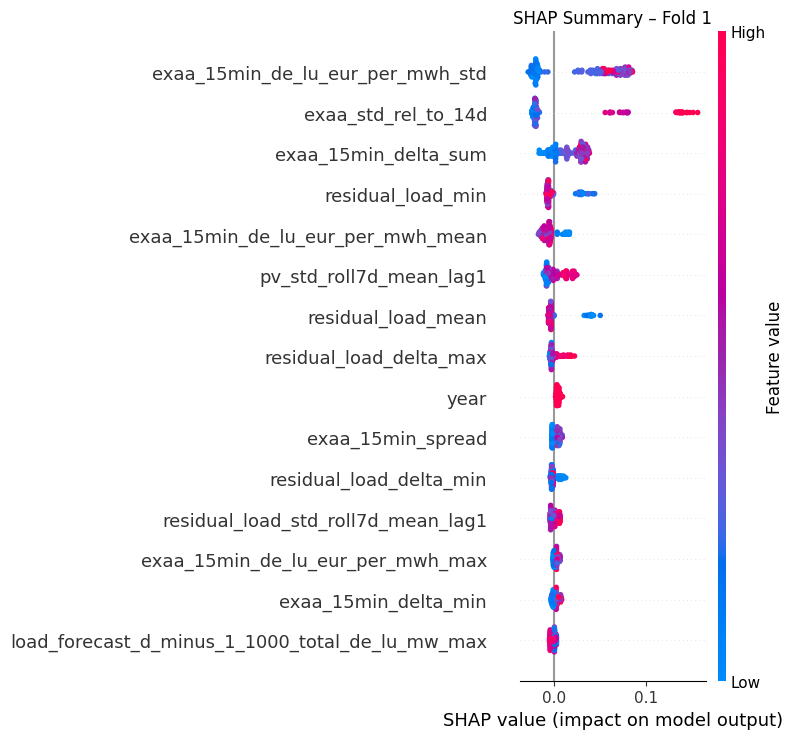

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12083
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

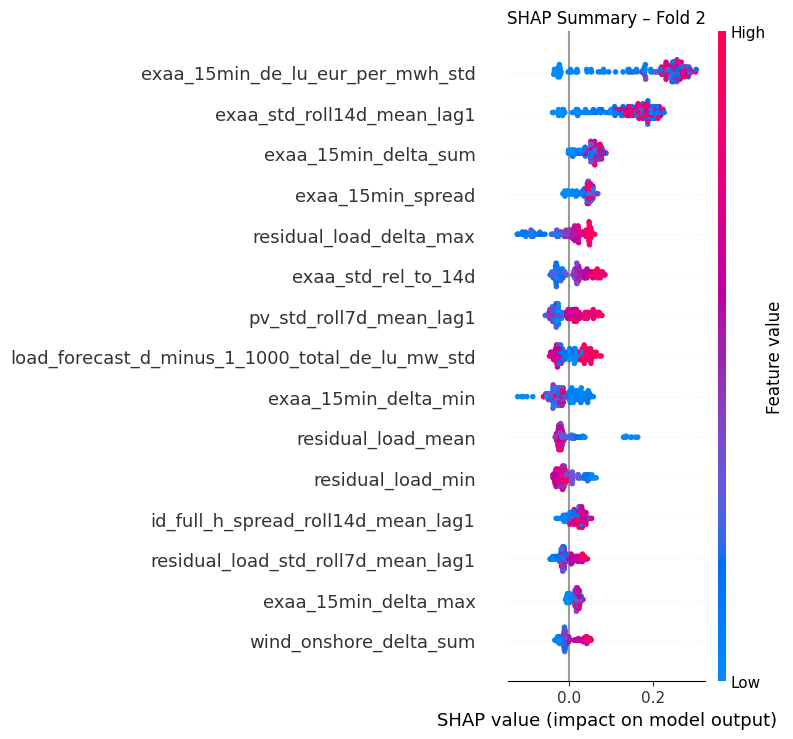

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12200
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

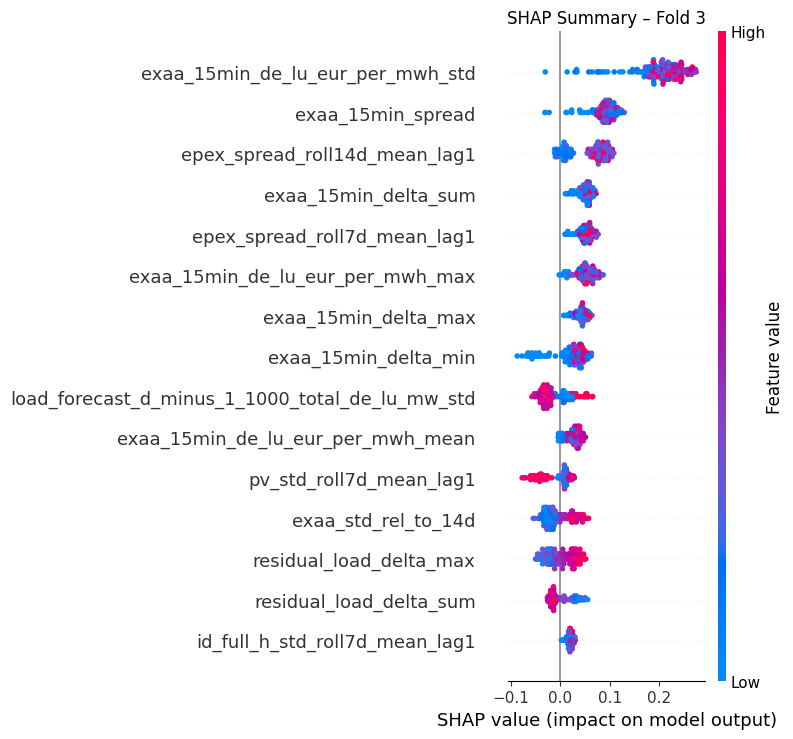

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12208
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

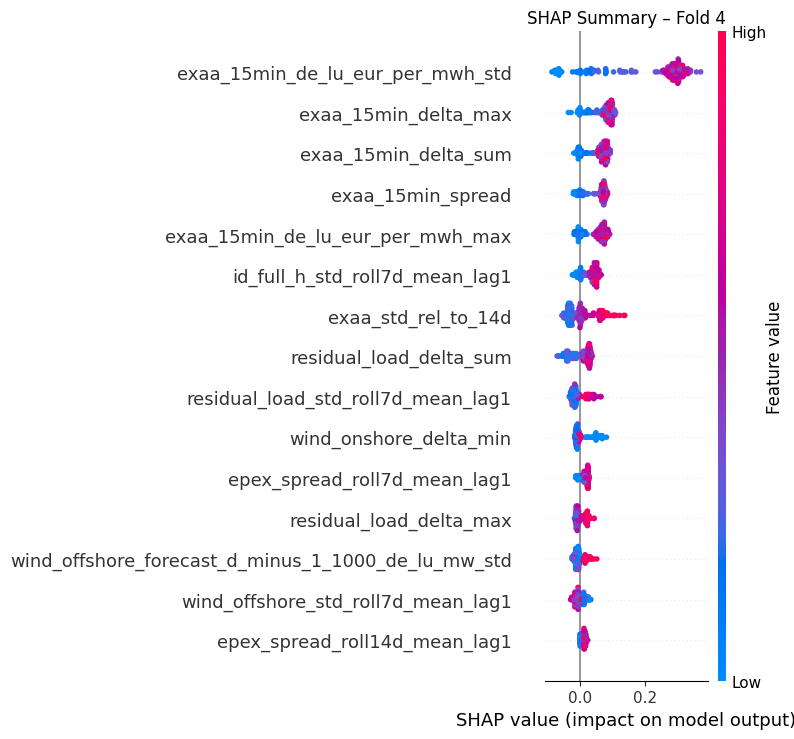

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12212
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

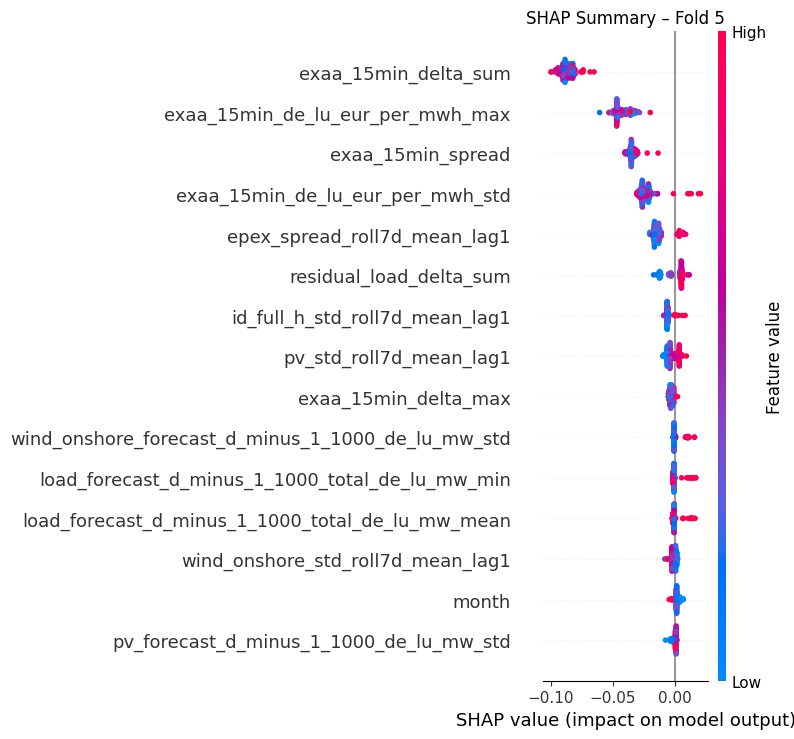

[LightGBM] [Info] Number of positive: 146, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12210
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

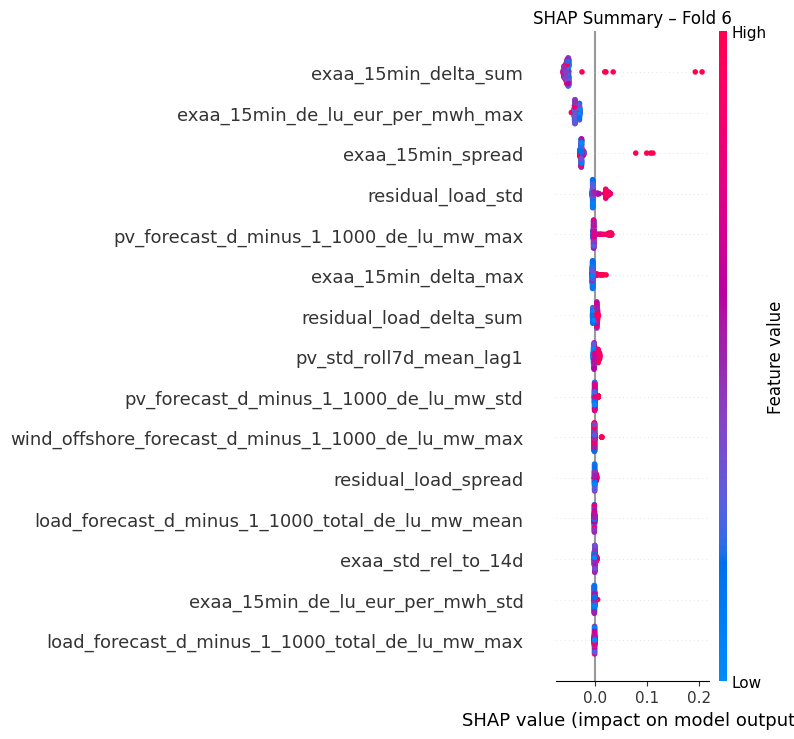

In [ ]:
import shap
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# ----------------------------
# Vorbereitung (wie zuvor)
# ----------------------------
df = df_daily.copy().reset_index(drop=True)
target = "profit"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# Rolling Window Parameter
train_size = 730
test_size  = 180
step_size  = 180
q_high     = 0.8

params = dict(
    objective="binary",
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# SHAP pro Fold
# ----------------------------
shap_results = []

fold = 0
start = 0

while start + train_size + test_size <= len(df):
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    explainer = shap.Explainer(
        clf,
        X_train,
        model_output="probability"
    )

    shap_exp = explainer(X_test)

    # Matrix: (n_samples, n_features)
    shap_vals = shap_exp.values

    assert shap_vals.ndim == 2
    assert shap_vals.shape[1] == X_test.shape[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_results.append(
        pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap,
            "fold": fold
        })
    )



    
    # Optional: SHAP summary plot pro Fold
    plt.figure()
    shap.summary_plot(
        shap_vals, X_test,
        feature_names=feature_cols,
        show=False,
        max_display=15
    )
    
    plt.title(f"SHAP Summary – Fold {fold}")
    plt.tight_layout()
    plt.show()
    
    start += step_size

shap_df = pd.concat(shap_results, ignore_index=True)



In [ ]:
# Aggregierte SHAP-Werte über alle Folds
shap_agg = (
    shap_df
    .groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(shap_agg.head(50))


                                                        mean       std
feature                                                               
exaa_15min_de_lu_eur_per_mwh_std                    0.116129  0.102704
exaa_15min_delta_sum                                0.054196  0.021074
exaa_15min_spread                                   0.042479  0.029656
exaa_15min_de_lu_eur_per_mwh_max                    0.031373  0.021322
exaa_std_roll14d_mean_lag1                          0.028755  0.056694
exaa_15min_delta_max                                0.023703  0.028506
exaa_std_rel_to_14d                                 0.021439  0.016808
epex_spread_roll7d_mean_lag1                        0.016927  0.018610
residual_load_delta_max                             0.012909  0.015179
pv_std_roll7d_mean_lag1                             0.012892  0.011778
exaa_15min_delta_min                                0.012809  0.015661
id_full_h_std_roll7d_mean_lag1                      0.012609  0.014228
epex_s